# 04 · OE5 — Modelo predictivo (XGBoost) y anticipación de picos
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.8 (modelo, validación cruzada temporal y anticipación de saturación).* **Requiere `03_OE4_conglomerados`.**


In [1]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from itertools import combinations
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score, silhouette_samples
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

c:\Users\ivanr\.conda\envs\pyfhel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


### Carga de insumos


In [2]:
import os
from pathlib import Path
import pandas as pd

# Raíz del proyecto: sube hasta encontrar un marcador del repo (sirve corra donde corra el kernel)
def raiz_proyecto(marcadores=('.git', 'requirements.txt', 'README.md')):
    d = Path.cwd().resolve()
    for cand in (d, *d.parents):
        if any((cand / m).exists() for m in marcadores):
            return cand
    return d

RAIZ = raiz_proyecto()
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

ipd_df     = pd.read_parquet(os.path.join(DATA_INT, 'panel_con_clusters.parquet'))
cluster_df = pd.read_parquet(os.path.join(DATA_INT, 'cluster_df.parquet'))
icp        = pd.read_parquet(os.path.join(DATA_INT, 'icp.parquet'))
print(f'Panel con conglomerado: {len(ipd_df):,} filas')


Panel con conglomerado: 7,957,878 filas


## 11. Modelo predictivo de demanda y anticipación de picos de saturación

Modelo supervisado (XGBoost) para predecir la demanda por estación y franja horaria, que permite anticipar picos de saturación proyectando el IPD esperado (demanda predicha sobre la cobertura ponderada). Se compara contra un modelo base de solo variables temporales para verificar el aporte estructural de los indicadores ICP y conglomerado, y contra otros algoritmos (Random Forest, LightGBM) para sustentar la elección del modelo final.

In [3]:
# =============================================
# PREPARACIÓN DE FEATURES
# =============================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Conglomerado SIN FUGA: el perfil de IPD y el K-Means se reajustan usando SOLO el
# periodo de entrenamiento (80% temporal), de modo que la etiqueta de cluster usada
# como predictor no incorpora informacion del conjunto de prueba. El cluster del OE4
# (periodo completo) se conserva para la caracterizacion descriptiva de hallazgos.
split_date = ipd_df['fecha'].quantile(0.8)
ipd_train  = ipd_df[ipd_df['fecha'] <= split_date]

perf_tr = ipd_train.groupby(['estacion', 'hora'])['ipd'].mean().unstack(fill_value=0)
perf_tr['ipd_mean'] = perf_tr.mean(axis=1)
perf_tr['ipd_std']  = perf_tr.iloc[:, :-1].std(axis=1)
perf_tr['ipd_max']  = perf_tr.iloc[:, :-2].max(axis=1)
perf_tr.columns = perf_tr.columns.astype(str)

scaler_cl = StandardScaler()
km_tr = KMeans(n_clusters=4, random_state=42, n_init=10)
perf_tr['cluster_tr'] = km_tr.fit_predict(scaler_cl.fit_transform(perf_tr))

# Alinear la numeracion con los conglomerados del OE4 (por mayoria de estaciones
# compartidas), para conservar la tipologia C0-C3 del capitulo de hallazgos.
ref = cluster_df.set_index('estacion')['cluster']
align = (perf_tr[['cluster_tr']].join(ref.rename('oe4')).dropna()
         .groupby('cluster_tr')['oe4'].agg(lambda s: int(s.mode().iloc[0])).to_dict())
perf_tr['cluster'] = perf_tr['cluster_tr'].map(align)
cluster_map = perf_tr['cluster'].to_dict()

ipd_df['cluster'] = ipd_df['estacion'].map(cluster_map)


# Concordancia con el cluster del OE4 (periodo completo): si es alta, la fuga era marginal
comp = perf_tr.join(ref.rename('oe4')).dropna(subset=['oe4'])
ari_tr = adjusted_rand_score(comp['oe4'].astype(int), comp['cluster'].astype(int))

del ipd_train, perf_tr, comp

station_codes = {s: i for i, s in enumerate(sorted(ipd_df['estacion'].unique()))}
ipd_df['estacion_code'] = ipd_df['estacion'].map(station_codes)

feature_cols  = ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo',
                 'icp', 'n_rutas', 'cluster', 'estacion_code']
base_features = ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'estacion_code']

model_df = ipd_df.dropna(subset=feature_cols + ['validaciones']).copy()
model_df['cluster'] = model_df['cluster'].astype(int)

print(f"Conglomerado reajustado solo con train (sin fuga al test).")
print(f"ARI vs cluster del OE4 (periodo completo) = {ari_tr:.3f}  (cercano a 1 => fuga marginal)")
print(f"Datos para modelo: {len(model_df):,} filas")
print(f"Features modelo base:     {base_features}")
print(f"Features modelo completo: {feature_cols}")

X = model_df[feature_cols]
y = model_df['validaciones']


Conglomerado reajustado solo con train (sin fuga al test).
ARI vs cluster del OE4 (periodo completo) = 0.879  (cercano a 1 => fuga marginal)
Datos para modelo: 7,957,878 filas
Features modelo base:     ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'estacion_code']
Features modelo completo: ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'icp', 'n_rutas', 'cluster', 'estacion_code']


In [4]:
# =============================================
# PARTICIÓN TEMPORAL (80/20)
# =============================================

# split_date ya definido en la preparacion de features (mismo corte para clusters y modelo)
train_mask = model_df['fecha'] <= split_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train):,} filas (hasta {split_date.strftime('%Y-%m-%d')})")
print(f"Test:  {len(X_test):,} filas (después)")

Train: 6,372,734 filas (hasta 2025-08-02)
Test:  1,585,144 filas (después)


In [5]:
# =============================================
# MODELO BASE (SIN ICP NI CONGLOMERADO)
# =============================================

xgb_params = dict(n_estimators=300, max_depth=8, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

xgb_base = XGBRegressor(**xgb_params)
xgb_base.fit(X_train[base_features], y_train)
y_pred_base = xgb_base.predict(X_test[base_features])

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print(f"MODELO BASE (solo variables temporales + estación)")
print(f"  RMSE: {rmse_base:.2f}")
print(f"  MAE:  {mae_base:.2f}")
print(f"  R²:   {r2_base:.4f}")

MODELO BASE (solo variables temporales + estación)
  RMSE: 80.48
  MAE:  38.48
  R²:   0.9124


In [6]:
# =============================================
# MODELO COMPLETO (CON ICP Y CONGLOMERADO)
# =============================================

xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X_train, y_train)
y_pred_full = xgb_full.predict(X_test)

rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))
r2_full = r2_score(y_test, y_pred_full)
mae_full = mean_absolute_error(y_test, y_pred_full)

print(f"MODELO COMPLETO (con ICP + conglomerado)")
print(f"  RMSE: {rmse_full:.2f}")
print(f"  MAE:  {mae_full:.2f}")
print(f"  R²:   {r2_full:.4f}")

print(f"\n{'='*50}")
print(f"CONTRIBUCIÓN DE LOS INDICADORES:")
print(f"  RMSE: {rmse_base:.2f} -> {rmse_full:.2f} ({(rmse_base-rmse_full)/rmse_base*100:.1f}% mejora)")
print(f"  R²:   {r2_base:.4f} -> {r2_full:.4f} (+{r2_full-r2_base:.4f})")

MODELO COMPLETO (con ICP + conglomerado)
  RMSE: 72.76
  MAE:  30.91
  R²:   0.9284

CONTRIBUCIÓN DE LOS INDICADORES:
  RMSE: 80.48 -> 72.76 (9.6% mejora)
  R²:   0.9124 -> 0.9284 (+0.0160)


In [7]:
# =============================================
# COMPARACIÓN: XGBoost vs Random Forest
# =============================================

rf = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    max_features=0.8, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Intentar LightGBM si está disponible
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    r2_lgb = r2_score(y_test, y_pred_lgb)
    mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
    has_lgb = True
except ImportError:
    has_lgb = False

print("=" * 60)
print("COMPARACIÓN DE ALGORITMOS (modelo completo)")
print("=" * 60)
print(f"{'Algoritmo':<20} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 50)
print(f"{'XGBoost':<20} {rmse_full:>10.2f} {mae_full:>10.2f} {r2_full:>10.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>10.2f} {mae_rf:>10.2f} {r2_rf:>10.4f}")
if has_lgb:
    print(f"{'LightGBM':<20} {rmse_lgb:>10.2f} {mae_lgb:>10.2f} {r2_lgb:>10.4f}")

COMPARACIÓN DE ALGORITMOS (modelo completo)
Algoritmo                  RMSE        MAE         R²
--------------------------------------------------
XGBoost                   72.76      30.91     0.9284
Random Forest            112.75      56.90     0.8280
LightGBM                  78.29      37.85     0.9171


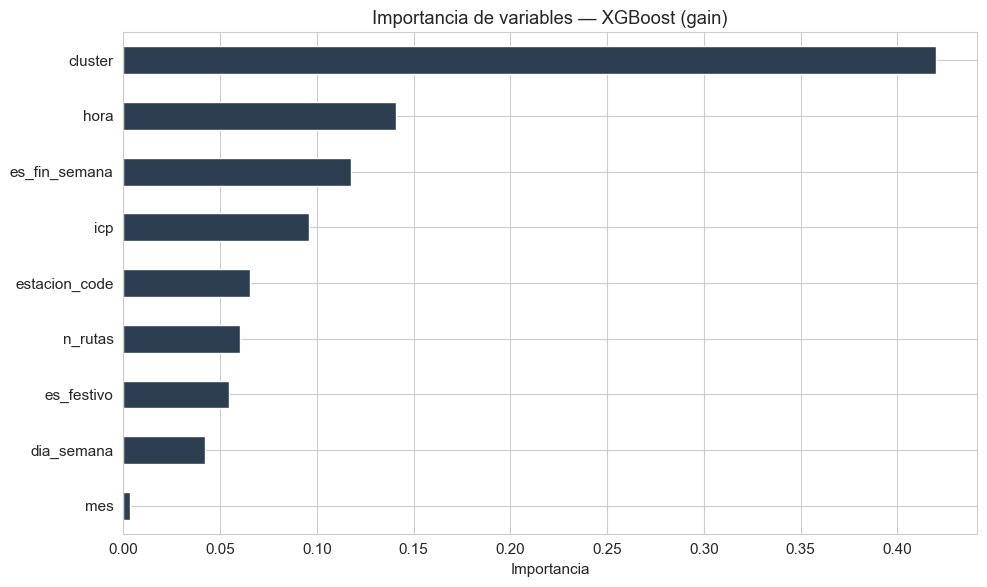

In [8]:
# =============================================
# IMPORTANCIA DE VARIABLES
# =============================================

importance = pd.Series(xgb_full.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='#2c3e50')
ax.set_title('Importancia de variables — XGBoost (gain)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig5_importancia_variables.png'), dpi=150, bbox_inches='tight')
plt.show()

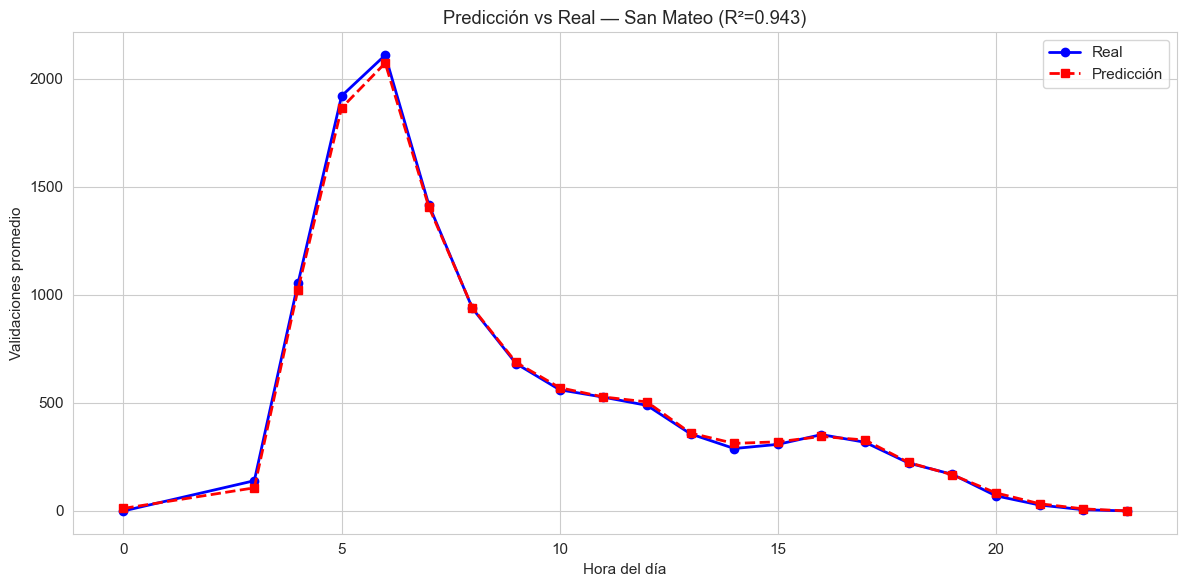

In [9]:
# =============================================
# PREDICCIÓN VS REAL — ESTACIÓN EJEMPLO
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full

station_r2 = {}
for est in test_df['estacion'].unique():
    mask = test_df['estacion'] == est
    if mask.sum() > 100:
        station_r2[est] = r2_score(test_df.loc[mask, 'validaciones'], test_df.loc[mask, 'y_pred'])

best_station = max(station_r2, key=station_r2.get)

est_data = test_df[test_df['estacion'] == best_station]
real_profile = est_data.groupby('hora')['validaciones'].mean()
pred_profile = est_data.groupby('hora')['y_pred'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(real_profile.index, real_profile.values, 'b-o', label='Real', linewidth=2)
ax.plot(pred_profile.index, pred_profile.values, 'r--s', label='Predicción', linewidth=2)
ax.set_title(f'Predicción vs Real — {best_station} (R²={station_r2[best_station]:.3f})')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Validaciones promedio')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig6_prediccion_vs_real.png'), dpi=150, bbox_inches='tight')
plt.show()

### Validación y diagnóstico del modelo

Validación cruzada temporal, análisis de residuos, RMSE desagregado por estación, interpretabilidad (SHAP y permutation importance) e intervalos de confianza por bootstrap.

In [10]:
# =============================================
# VALIDACIÓN CRUZADA TEMPORAL
# =============================================

# Dividir en 5 ventanas temporales
model_df_sorted = model_df.sort_values('fecha')
total = len(model_df_sorted)
n_folds = 5
fold_size = total // n_folds

cv_results = []
print("=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===\n")

for fold in range(n_folds):
    # Train: todo lo anterior al fold. Test: el fold.
    test_start = fold * fold_size
    test_end = (fold + 1) * fold_size if fold < n_folds - 1 else total
    
    if fold == 0:
        continue  # Skip: no hay datos de entrenamiento antes del primer fold
    
    train_idx = range(0, test_start)
    test_idx = range(test_start, test_end)
    
    X_tr = model_df_sorted.iloc[list(train_idx)][feature_cols]
    y_tr = model_df_sorted.iloc[list(train_idx)]['validaciones']
    X_te = model_df_sorted.iloc[list(test_idx)][feature_cols]
    y_te = model_df_sorted.iloc[list(test_idx)]['validaciones']
    
    xgb_cv = XGBRegressor(**xgb_params)
    xgb_cv.fit(X_tr, y_tr)
    y_pred_cv = xgb_cv.predict(X_te)
    
    rmse_cv = np.sqrt(mean_squared_error(y_te, y_pred_cv))
    r2_cv = r2_score(y_te, y_pred_cv)
    mae_cv = mean_absolute_error(y_te, y_pred_cv)
    
    fecha_start = model_df_sorted.iloc[test_start]['fecha']
    fecha_end = model_df_sorted.iloc[min(test_end-1, total-1)]['fecha']
    
    cv_results.append({
        'fold': fold, 'train_size': len(train_idx), 'test_size': len(test_idx),
        'fecha_test': f"{fecha_start.strftime('%Y-%m')} a {fecha_end.strftime('%Y-%m')}",
        'rmse': rmse_cv, 'mae': mae_cv, 'r2': r2_cv
    })
    print(f"Fold {fold}: train={len(train_idx):,}, test={len(test_idx):,}, "
          f"periodo={fecha_start.strftime('%Y-%m')}–{fecha_end.strftime('%Y-%m')}, "
          f"RMSE={rmse_cv:.2f}, R²={r2_cv:.4f}")

cv_df = pd.DataFrame(cv_results)
print(f"\nPromedio: RMSE={cv_df['rmse'].mean():.2f} ± {cv_df['rmse'].std():.2f}, "
      f"R²={cv_df['r2'].mean():.4f} ± {cv_df['r2'].std():.4f}")

=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===

Fold 1: train=1,591,575, test=1,591,575, periodo=2024-05–2024-10, RMSE=72.68, R²=0.9262
Fold 2: train=3,183,150, test=1,591,575, periodo=2024-10–2025-03, RMSE=74.31, R²=0.9204
Fold 3: train=4,774,725, test=1,591,575, periodo=2025-03–2025-08, RMSE=69.46, R²=0.9311
Fold 4: train=6,366,300, test=1,591,578, periodo=2025-08–2025-12, RMSE=73.03, R²=0.9277

Promedio: RMSE=72.37 ± 2.06, R²=0.9264 ± 0.0045


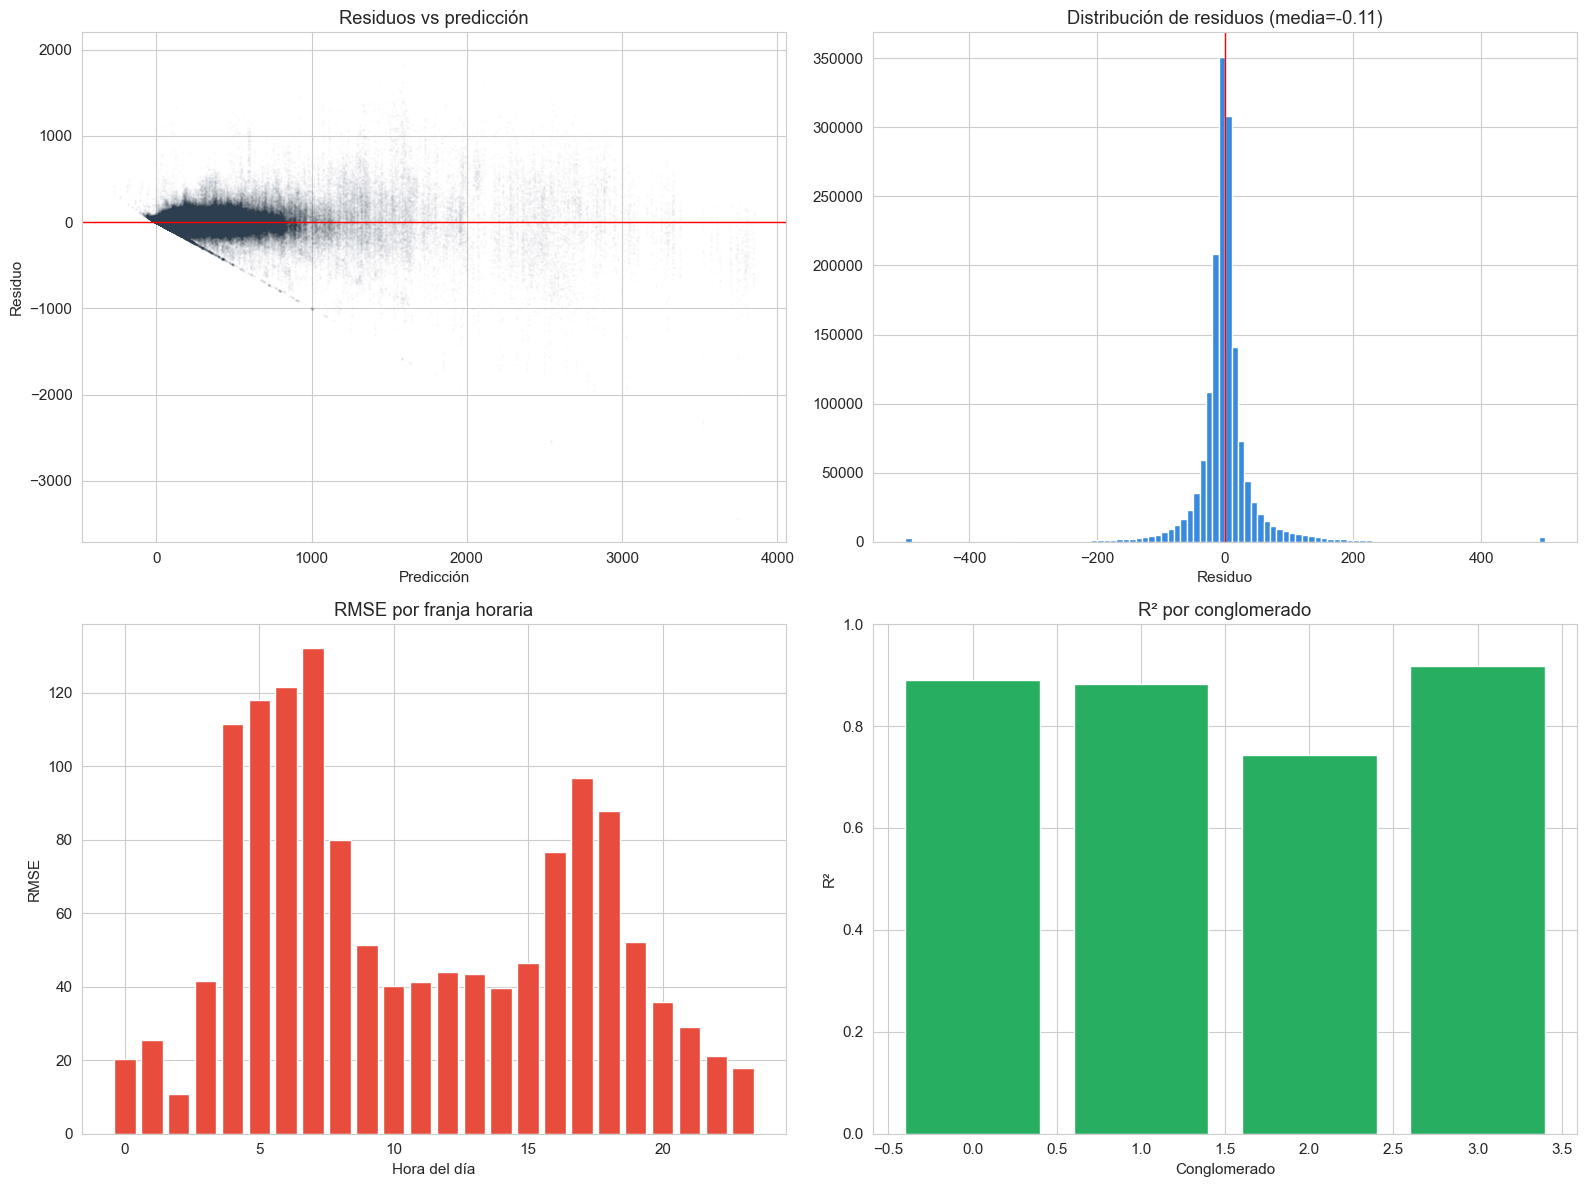

In [11]:
# =============================================
# ANÁLISIS DE RESIDUOS
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full
test_df['residuo'] = test_df['validaciones'] - test_df['y_pred']
test_df['residuo_pct'] = test_df['residuo'] / (test_df['validaciones'] + 1) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Residuos vs predicción
axes[0,0].scatter(test_df['y_pred'], test_df['residuo'], alpha=0.01, s=1, c='#2c3e50')
axes[0,0].axhline(y=0, color='red', linewidth=1)
axes[0,0].set_xlabel('Predicción')
axes[0,0].set_ylabel('Residuo')
axes[0,0].set_title('Residuos vs predicción')

# Panel 2: Distribución de residuos
axes[0,1].hist(test_df['residuo'].clip(-500, 500), bins=100, color='#378ADD', edgecolor='white')
axes[0,1].axvline(x=0, color='red', linewidth=1)
axes[0,1].set_xlabel('Residuo')
axes[0,1].set_title(f'Distribución de residuos (media={test_df["residuo"].mean():.2f})')

# Panel 3: RMSE por hora
rmse_hora = test_df.groupby('hora').apply(
    lambda g: np.sqrt(mean_squared_error(g['validaciones'], g['y_pred']))
).reset_index(name='rmse')
axes[1,0].bar(rmse_hora['hora'], rmse_hora['rmse'], color='#e74c3c')
axes[1,0].set_xlabel('Hora del día')
axes[1,0].set_ylabel('RMSE')
axes[1,0].set_title('RMSE por franja horaria')

# Panel 4: R² por conglomerado
r2_cluster = test_df.groupby('cluster').apply(
    lambda g: r2_score(g['validaciones'], g['y_pred']) if len(g) > 10 else np.nan
).reset_index(name='r2')
r2_cluster['cluster'] = r2_cluster['cluster'].astype(int)
axes[1,1].bar(r2_cluster['cluster'], r2_cluster['r2'], color='#27ae60')
axes[1,1].set_xlabel('Conglomerado')
axes[1,1].set_ylabel('R²')
axes[1,1].set_title('R² por conglomerado')
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_analisis_residuos.png'), dpi=150, bbox_inches='tight')
plt.show()

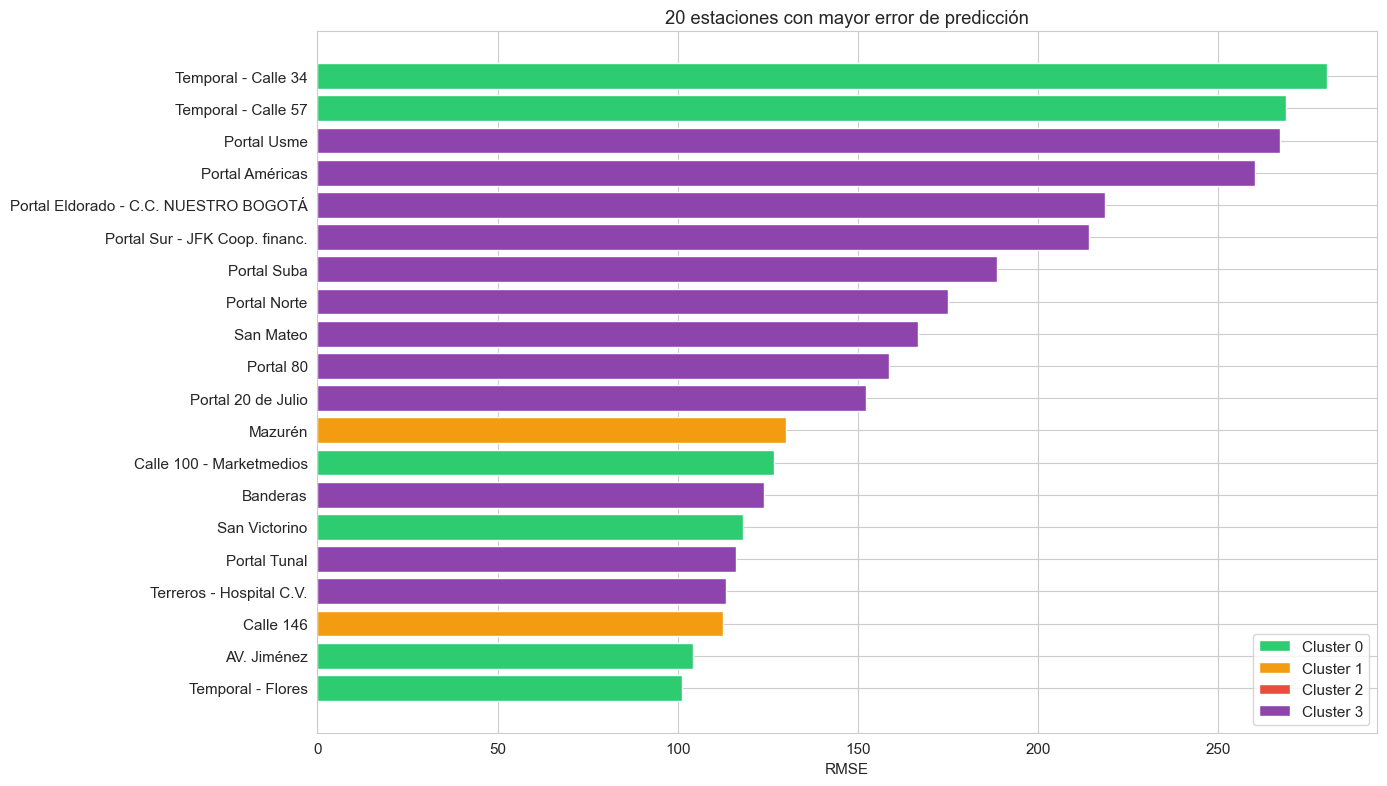

Estaciones con R² < 0.80: 42
Estaciones con R² > 0.95: 0


In [12]:
# =============================================
# RMSE DESAGREGADO POR ESTACIÓN
# =============================================

rmse_est = test_df.groupby('estacion').apply(
    lambda g: pd.Series({
        'rmse': np.sqrt(mean_squared_error(g['validaciones'], g['y_pred'])),
        'r2': r2_score(g['validaciones'], g['y_pred']) if len(g) > 10 else np.nan,
        'n': len(g),
        'cluster': int(g['cluster'].mode().iloc[0]) if len(g) > 0 else -1
    })
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
worst_20 = rmse_est.nlargest(20, 'rmse')
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#8e44ad'}
bar_colors = [colors_map.get(int(c), '#999') for c in worst_20['cluster']]
ax.barh(range(len(worst_20)), worst_20['rmse'].values, color=bar_colors)
ax.set_yticks(range(len(worst_20)))
ax.set_yticklabels(worst_20['estacion'].values)
ax.set_xlabel('RMSE')
ax.set_title('20 estaciones con mayor error de predicción')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'Cluster {k}') for k, c in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_rmse_por_estacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Estaciones con R² < 0.80: {(rmse_est['r2'] < 0.80).sum()}")
print(f"Estaciones con R² > 0.95: {(rmse_est['r2'] > 0.95).sum()}")

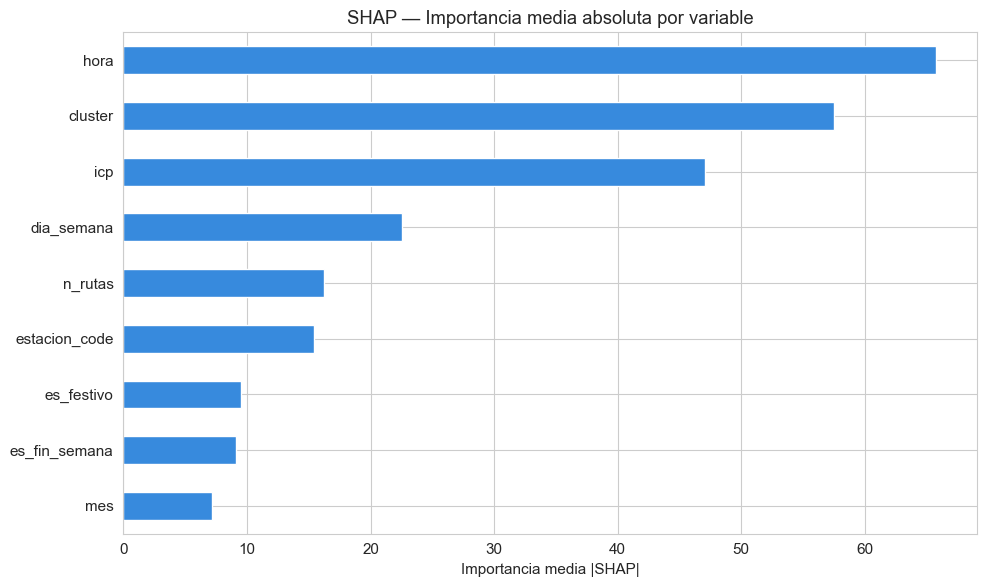

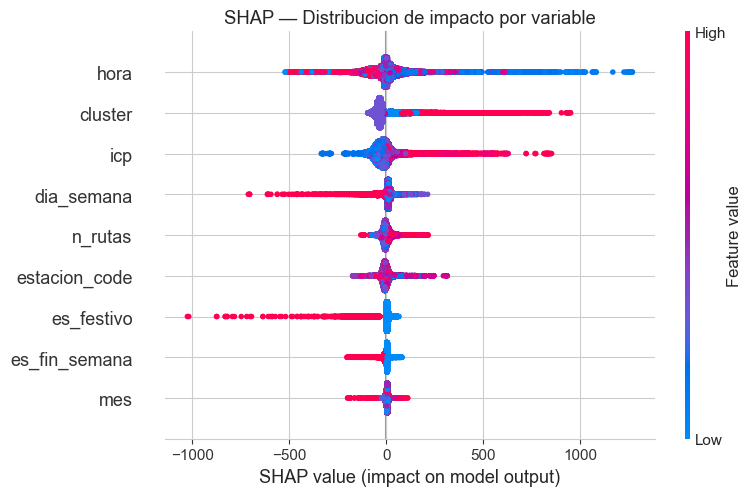

=== COMPARACION: GAIN vs SHAP (normalizado) ===
                gain   shap
hora           0.141  0.263
cluster        0.420  0.230
icp            0.096  0.188
dia_semana     0.042  0.090
n_rutas        0.060  0.065
estacion_code  0.066  0.062
es_festivo     0.055  0.038
es_fin_semana  0.117  0.036
mes            0.003  0.029


In [13]:
# =============================================
# SHAP VALUES
# =============================================
# Se calculan los valores SHAP con la funcion nativa de XGBoost (pred_contribs),
# que es TreeSHAP, para evitar la incompatibilidad de versiones entre shap y
# xgboost al cargar el modelo. shap se usa solo para la visualizacion.
import xgboost as xgb

# Muestra para velocidad
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(50000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

# SHAP nativo de XGBoost: la ultima columna es el sesgo (base value), se descarta
dmatrix = xgb.DMatrix(X_sample)
shap_contribs = xgb_full.get_booster().predict(dmatrix, pred_contribs=True)
shap_values = shap_contribs[:, :-1]

# Importancia media |SHAP| por variable
shap_mean = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)

# Grafico 1: barra de importancia media |SHAP| (controlado, sin summary_plot)
fig, ax = plt.subplots(figsize=(10, 6))
shap_mean.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_xlabel('Importancia media |SHAP|')
ax.set_title('SHAP — Importancia media absoluta por variable')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_shap_importancia.png'), dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: beeswarm (distribucion de impacto). Figura propia de shap.
try:
    shap.summary_plot(shap_values, X_sample, max_display=10, show=False)
    plt.title('SHAP — Distribucion de impacto por variable')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, 'fig_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"(No se pudo generar el beeswarm: {e})")

# Comparacion gain vs SHAP (normalizado)
gain_importance = pd.Series(xgb_full.feature_importances_, index=feature_cols)
comp_imp = pd.DataFrame({
    'gain': gain_importance / gain_importance.sum(),
    'shap': shap_mean / shap_mean.sum()
}).sort_values('shap', ascending=False)

print("=== COMPARACION: GAIN vs SHAP (normalizado) ===")
print(comp_imp.round(3).to_string())

=== PERMUTATION IMPORTANCE ===
     variable  importance_mean  importance_std
         hora     82469.722754     1266.768099
      cluster     35502.994238      341.320469
          icp     28027.039941      296.981715
   dia_semana      9569.130957      222.580286
   es_festivo      5806.637988      374.604460
estacion_code      5218.278613       70.388101
      n_rutas      4769.165527       69.295445
es_fin_semana      2304.270850       76.808084
          mes       672.564111       48.040212


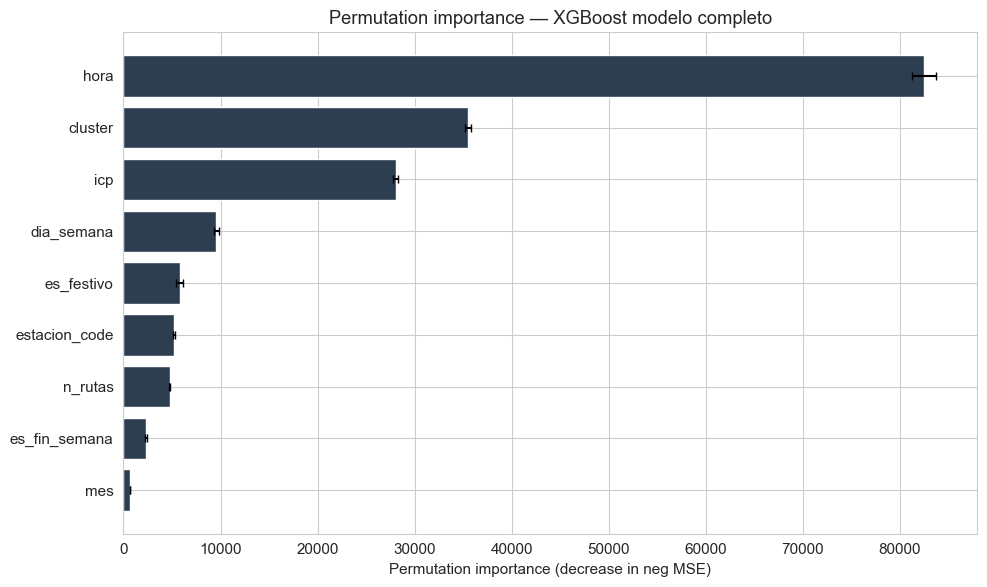

In [14]:
# =============================================
# PERMUTATION IMPORTANCE
# =============================================

from sklearn.inspection import permutation_importance

# Usar muestra para velocidad
sample_size = min(100000, len(X_test))
sample_idx = np.random.RandomState(42).choice(len(X_test), size=sample_size, replace=False)

perm_result = permutation_importance(
    xgb_full, X_test.iloc[sample_idx], y_test.iloc[sample_idx],
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'variable': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("=== PERMUTATION IMPORTANCE ===")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
perm_df_sorted = perm_df.sort_values('importance_mean')
ax.barh(perm_df_sorted['variable'], perm_df_sorted['importance_mean'],
        xerr=perm_df_sorted['importance_std'], color='#2c3e50', capsize=3)
ax.set_xlabel('Permutation importance (decrease in neg MSE)')
ax.set_title('Permutation importance — XGBoost modelo completo')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_permutation_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Bootstrap con 1000 iteraciones...

=== INTERVALOS DE CONFIANZA 95% (BOOTSTRAP) ===
  RMSE: 72.24 — 73.32 (punto: 72.76)
  R²:   0.9273 — 0.9294 (punto: 0.9284)

=== DIFERENCIA BASE vs COMPLETO (bootstrap) ===
  ΔRMSE: 6.97 — 8.50 (punto: 7.72)
  ΔR²:   0.0144 — 0.0175 (punto: 0.0160)

  En 100.0% de las muestras bootstrap, el modelo completo supera al base.


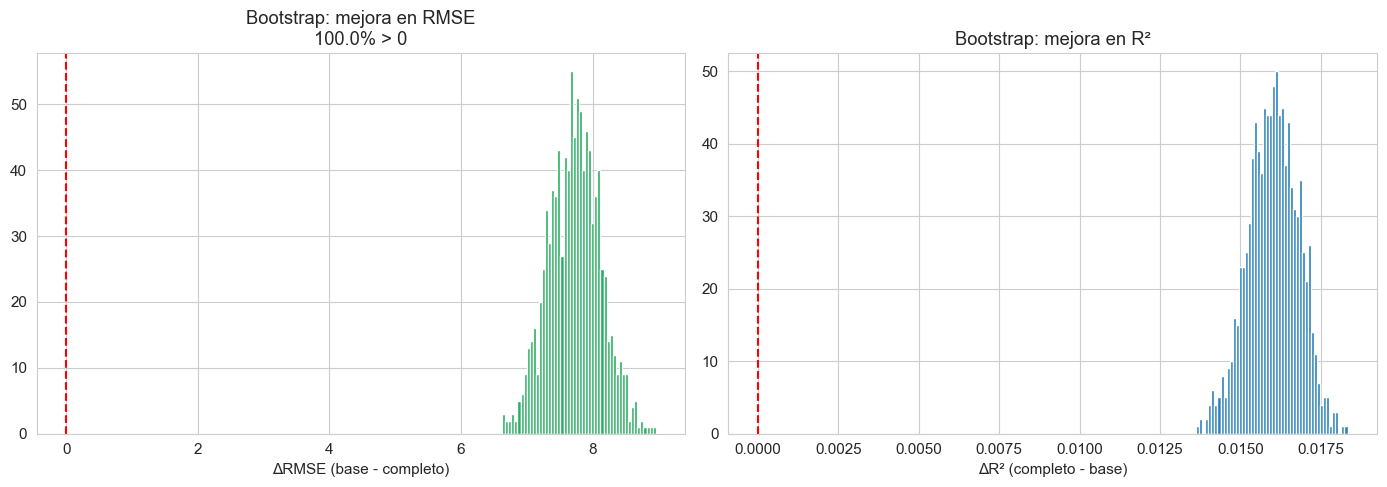

In [15]:
# =============================================
# BOOTSTRAP: INTERVALOS DE CONFIANZA PARA MÉTRICAS
# =============================================

n_bootstrap = 1000
boot_rmse = []
boot_r2 = []

test_indices = np.arange(len(y_test))

print(f"Bootstrap con {n_bootstrap} iteraciones...\n")
np.random.seed(42)
for i in range(n_bootstrap):
    idx = np.random.choice(test_indices, size=len(test_indices), replace=True)
    y_true_boot = y_test.iloc[idx].values
    y_pred_boot = y_pred_full[idx]
    boot_rmse.append(np.sqrt(mean_squared_error(y_true_boot, y_pred_boot)))
    boot_r2.append(r2_score(y_true_boot, y_pred_boot))

boot_rmse = np.array(boot_rmse)
boot_r2 = np.array(boot_r2)

print("=== INTERVALOS DE CONFIANZA 95% (BOOTSTRAP) ===")
print(f"  RMSE: {np.percentile(boot_rmse, 2.5):.2f} — {np.percentile(boot_rmse, 97.5):.2f} (punto: {rmse_full:.2f})")
print(f"  R²:   {np.percentile(boot_r2, 2.5):.4f} — {np.percentile(boot_r2, 97.5):.4f} (punto: {r2_full:.4f})")

# Comparar con modelo base
boot_rmse_base = []
boot_r2_base = []
for i in range(n_bootstrap):
    idx = np.random.choice(test_indices, size=len(test_indices), replace=True)
    y_true_boot = y_test.iloc[idx].values
    y_pred_boot_base = y_pred_base[idx]
    boot_rmse_base.append(np.sqrt(mean_squared_error(y_true_boot, y_pred_boot_base)))
    boot_r2_base.append(r2_score(y_true_boot, y_pred_boot_base))

boot_rmse_base = np.array(boot_rmse_base)
boot_r2_base = np.array(boot_r2_base)

delta_rmse = boot_rmse_base - boot_rmse
delta_r2 = boot_r2 - boot_r2_base

print(f"\n=== DIFERENCIA BASE vs COMPLETO (bootstrap) ===")
print(f"  ΔRMSE: {np.percentile(delta_rmse, 2.5):.2f} — {np.percentile(delta_rmse, 97.5):.2f} (punto: {rmse_base-rmse_full:.2f})")
print(f"  ΔR²:   {np.percentile(delta_r2, 2.5):.4f} — {np.percentile(delta_r2, 97.5):.4f} (punto: {r2_full-r2_base:.4f})")

# ¿La mejora es significativa?
pct_rmse_positive = (delta_rmse > 0).mean() * 100
print(f"\n  En {pct_rmse_positive:.1f}% de las muestras bootstrap, el modelo completo supera al base.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(delta_rmse, bins=50, color='#27ae60', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('ΔRMSE (base - completo)')
axes[0].set_title(f'Bootstrap: mejora en RMSE\n{pct_rmse_positive:.1f}% > 0')

axes[1].hist(delta_r2, bins=50, color='#2980b9', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('ΔR² (completo - base)')
axes[1].set_title(f'Bootstrap: mejora en R²')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_bootstrap_metricas.png'), dpi=150, bbox_inches='tight')
plt.show()

### Anticipación de picos de saturación (cierra el OE5)

In [ ]:
# =============================================================
# ANTICIPACIÓN DE PICOS DE SATURACIÓN  
# -------------------------------------------------------------
#
# Umbral: IPD esperado = demanda predicha / ICP de la estación
#   - Pico de saturación:  IPD esperado >= 1.0  (la demanda proyectada
#                          iguala o supera la cobertura ponderada)
#   - Pico crítico:        IPD esperado >= 1.5
#
# La celda evalúa qué tan bien las predicciones del modelo anticipan
# la saturación realmente observada en el conjunto de prueba.
# =============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

UMBRAL_SAT  = 1.0
UMBRAL_CRIT = 1.5

# test_df viene de la celda 33: tiene 'validaciones', 'y_pred', 'icp', 'estacion', 'hora'
sat = test_df[test_df['icp'] > 0].copy()
sat['ipd_real']     = sat['validaciones'] / sat['icp']
sat['ipd_esperado'] = sat['y_pred']       / sat['icp']

# Etiquetas observadas vs. anticipadas por el modelo
sat['sat_real']  = (sat['ipd_real']     >= UMBRAL_SAT ).astype(int)
sat['sat_pred']  = (sat['ipd_esperado'] >= UMBRAL_SAT ).astype(int)
sat['crit_real'] = (sat['ipd_real']     >= UMBRAL_CRIT).astype(int)
sat['crit_pred'] = (sat['ipd_esperado'] >= UMBRAL_CRIT).astype(int)


def evaluar(y_true, y_pred, etiqueta):
    cm = confusion_matrix(y_true, y_pred)
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {etiqueta} ---")
    print(f"  Picos observados:  {int(y_true.sum()):,}")
    print(f"  Picos anticipados: {int(y_pred.sum()):,}")
    print(f"  Precisión: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
    print(f"  Matriz de confusión [[TN FP] [FN TP]]:\n{cm}\n")
    return p, r, f1


print("=" * 60)
print("ANTICIPACIÓN DE PICOS DE SATURACIÓN — CONJUNTO DE PRUEBA")
print(f"Registros evaluados: {len(sat):,}")
print("=" * 60 + "\n")

evaluar(sat['sat_real'],  sat['sat_pred'],  f"Saturación (IPD esperado >= {UMBRAL_SAT})")
evaluar(sat['crit_real'], sat['crit_pred'], f"Saturación crítica (IPD esperado >= {UMBRAL_CRIT})")

# Estaciones donde más se anticipan picos de saturación
resumen_estacion = (
    sat.groupby('estacion')
       .agg(intervalos=('sat_pred', 'size'),
            picos_anticipados=('sat_pred', 'sum'),
            picos_observados=('sat_real', 'sum'),
            ipd_esperado_max=('ipd_esperado', 'max'))
       .assign(tasa_anticipada=lambda d: d['picos_anticipados'] / d['intervalos'])
       .sort_values('picos_anticipados', ascending=False)
       .head(15)
)
print("Top 15 estaciones por picos de saturación anticipados:")
print(resumen_estacion.round(3).to_string())

# Franjas horarias con mayor proporción de picos anticipados
resumen_hora = (sat.groupby('hora')['sat_pred'].mean()
                   .sort_values(ascending=False).head(8))
print("\nFranjas horarias con mayor proporción de picos anticipados (%):")
print((resumen_hora * 100).round(1).to_string())


ANTICIPACIÓN DE PICOS DE SATURACIÓN — CONJUNTO DE PRUEBA
Registros evaluados: 1,585,144

--- Saturación (IPD esperado >= 1.0) ---
  Picos observados:  14,675
  Picos anticipados: 11,092
  Precisión: 0.758 | Recall: 0.573 | F1: 0.653
  Matriz de confusión [[TN FP] [FN TP]]:
[[1567786    2683]
 [   6266    8409]]

--- Saturación crítica (IPD esperado >= 1.5) ---
  Picos observados:  2,032
  Picos anticipados: 784
  Precisión: 0.594 | Recall: 0.229 | F1: 0.331
  Matriz de confusión [[TN FP] [FN TP]]:
[[1582794     318]
 [   1566     466]]

Top 15 estaciones por picos de saturación anticipados:
                                       intervalos  picos_anticipados  picos_observados  ipd_esperado_max  tasa_anticipada
estacion                                                                                                                 
Pradera - Plaza Central                     12234               1308              1018             1.799            0.107
Calle 100 - Marketmedios            

## 12. Exportación de resultados

In [17]:
# =============================================
# GUARDAR RESULTADOS
# =============================================

icp.to_csv(os.path.join(OUT_TAB, 'icp_estaciones.csv'), index=False)
print(f"Guardado: icp_estaciones.csv ({len(icp)} estaciones)")

ipd_export = ipd_df[['estacion', 'fecha', 'intervalo', 'hora', 'dia_semana', 'mes',
                      'validaciones', 'icp', 'n_rutas', 'ipd', 'cluster']].copy()
ipd_export.to_csv(os.path.join(OUT_TAB, 'ipd_completo.csv'), index=False)
print(f"Guardado: ipd_completo.csv ({len(ipd_export):,} filas)")

cluster_df.to_csv(os.path.join(OUT_TAB, 'conglomerados_estaciones.csv'), index=False)
print(f"Guardado: conglomerados_estaciones.csv ({len(cluster_df)} estaciones)")

metricas = pd.DataFrame({
    'Modelo': ['Base (sin ICP/conglomerado)', 'Completo (con ICP/conglomerado)', 'Random Forest (completo)'],
    'RMSE': [rmse_base, rmse_full, rmse_rf],
    'MAE': [mae_base, mae_full, mae_rf],
    'R2': [r2_base, r2_full, r2_rf]
})
metricas.to_csv(os.path.join(OUT_TAB, 'metricas_modelo.csv'), index=False)
print(f"Guardado: metricas_modelo.csv")
print(f"\nTodos los resultados exportados.")

Guardado: icp_estaciones.csv (216 estaciones)
Guardado: ipd_completo.csv (7,957,878 filas)
Guardado: conglomerados_estaciones.csv (144 estaciones)
Guardado: metricas_modelo.csv

Todos los resultados exportados.
